In [43]:
# Another example: Cell lineage analysis in hyperbolic space on the Paul dataset
import numpy as np
import pandas as pd
import seaborn as sn
import pylab as plt

import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import MHMDS.quality_metrics as qms

# simple PCA
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats

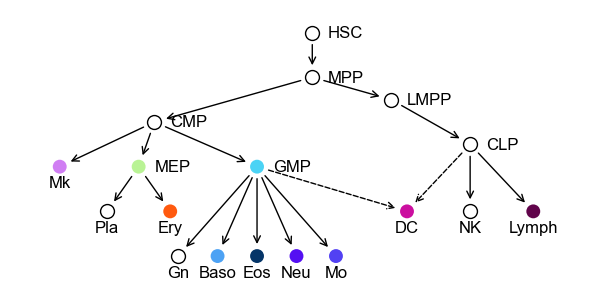

In [13]:
G = nx.DiGraph()

solid_edges = [
    ("HSC", "MPP"),("MPP", "CMP"),("MPP", "LMPP"),("CMP", "Mk"),
    ("CMP", "MEP"),("CMP", "GMP"),("MEP", "Pla"),("MEP", "Ery"),
    ("GMP", "Gn"),("GMP", "Baso"),("GMP", "Eos"),("GMP", "Neu"),
    ("GMP", "Mo"),("LMPP", "CLP"),("CLP", "NK"),("CLP", "Lymph"),
]

dashed_edges = [
    ("GMP", "DC"),("CLP", "DC"),
]

G.add_edges_from(solid_edges + dashed_edges)
pos = {
    "HSC": (0, 5),
    "MPP": (0, 4),

    "CMP": (-2, 3),"LMPP": (1, 3.5),

    "Mk": (-3.2, 2),"MEP": (-2.2, 2),"GMP": (-0.7, 2),

    "Pla": (-2.6, 1),"Ery": (-1.8, 1),

    "Gn": (-2.2+0.5, 0),"Baso": (-1.7+0.5, 0),"Eos": (-1.2+0.5, 0),"Neu": (-0.7+0.5, 0),"Mo": (-0.2+0.5, 0),

    "CLP": (2, 2.5),"DC": (1.2, 1),"NK": (2.0, 1),"Lymph": (2.8, 1),
}

hollow_nodes = ["HSC", "MPP", "CMP", "LMPP", "CLP", "Pla", "Gn","NK"]
filled_nodes = [n for n in G.nodes() if n not in hollow_nodes]

NODE_COLOR = {
    "Mk": "#D07EF3",
    "MEP": "#b9f395","Ery": "#ff5a0f",
    "GMP": "#4bd3f5","Baso": "#4da2f4","Eos": "#053568","Neu": "#5410f2","Mo": "#5241f3",
    "DC": "#cb0f9f",
    "Lymph": "#61044b",
}

fig, ax = plt.subplots(figsize=(6, 3))

nx.draw_networkx_edges(
    G, pos,
    edgelist=solid_edges,
    arrowstyle="->",
    arrowsize=12,
    width=1,
    ax=ax
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=dashed_edges,
    arrowstyle="->",
    arrowsize=12,
    width=1,
    style="dashed",
    ax=ax
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=hollow_nodes,
    node_size=100,
    node_color="white",
    edgecolors="black",
    linewidths=1,
    ax=ax
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=filled_nodes,
    node_size=100,
    node_color=[NODE_COLOR[n] for n in filled_nodes],
    edgecolors="none",
    ax=ax
)
label_right = {
    "HSC", "MPP", "CMP", "LMPP", "CLP", "MEP", "GMP"
}

label_bottom = {
    "Mk", "Pla", "Ery",
    "Gn", "Baso", "Eos", "Neu", "Mo",
    "DC", "NK", "Lymph"
}

for n, (x, y) in pos.items():
    if n in label_bottom:
        ax.text(
            x, y - 0.2, n,
            ha="center", va="top",
            fontdict={"fontsize": 12}
        )
    elif n in label_right:
        ax.text(
            x + 0.2, y, n,
            ha="left", va="center",
            fontdict={"fontsize": 12}
        )

ax.set_axis_off()
plt.tight_layout()
plt.show()


In [14]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)


In [15]:
mycolorseq = ['#f90e11','#ff5a0f','#ff9a0a','#f9d806',
            '#e8f04a','#c8f27e','#b9f395',
            "#D07EF3",
            '#5af6d9','#4bd3f5',
            '#cb0f9f',
            "#22af2d",'#4da2f4',
            '#5072f3','#5241f3',
            '#5410f2',"#4f9609",
            "#053568","#61044b"]
# # # make all outliers gray
# mycolorseq = ['#f90e11','#ff5a0f','#ff9a0a','#f9d806',
#             '#e8f04a','#c8f27e','#b9f395',
#             "#baadad",
#             '#5af6d9','#4bd3f5',
#             '#baadad',
#             "#22af2d",'#4da2f4',
#             '#5072f3','#5241f3',
#             '#5410f2',"#4f9609",
#             "#baadad","#baadad"]

In [16]:
# get PCA and UMAP, and compute Qlocal, Qglobal
def get_pca_umap(featmat,dim):
    # get PCA and umap embedding in the same dimension
    pca = PCA(n_components=dim)
    pcmat = pca.fit_transform(featmat)

    reducer = umap.UMAP(n_components=dim,random_state=42)
    umapmat = reducer.fit_transform(featmat)

    return pcmat,umapmat

def compute_quality_metrics(featmat,pcoords,pcmat,umapmat,plot=False):
    distmat = emb.get_dmat_euc(featmat)
    # compute Q local and Q global
    qlocal, qglobal, _ = qms.get_quality_metrics(distmat,emb.get_dmat_poin(pcoords))

    # compute Q local and Q global
    qlocal_pca, qglobal_pca, _ = qms.get_quality_metrics(distmat,emb.get_dmat_euc(pcmat))
    qlocal_umap, qglobal_umap, _ = qms.get_quality_metrics(distmat,emb.get_dmat_euc(umapmat))

    # visualization
    # scatter plot of Q local and Q global for PCA, UMAP and hMDS
    if plot:
        fig, ax = plt.subplots()
        ax.scatter(qlocal, qglobal, label='hMDS')
        ax.scatter(qlocal_pca, qglobal_pca, label='PCA')
        ax.scatter(qlocal_umap, qglobal_umap, label='UMAP')
        ax.set_xlabel('Q local')
        ax.set_ylabel('Q global')
        ax.legend()
        plt.show()

    return {'hyperbolic':[qlocal, qglobal],
                          'pca':[qlocal_pca, qglobal_pca],
                          'umap':[qlocal_umap, qglobal_umap]}


In [17]:
# get tangent coordinates
def get_tangent_coords(pcoords):
    N_sample = pcoords.shape[0]
    data_recenter = emb.perform_recenter(pcoords,np.arange(N_sample))
    tangent_coords = emb.logmap(data_recenter)
    return tangent_coords

In [18]:
# load data: metadata and features
metadata = pd.read_csv('../data/metadata/Paul_metadata.csv',index_col=0)

# load original feature matrix
featmat = np.loadtxt('../data/FeatMat_Paul_PCA100/FeatMat_Paul_PCA100.txt')

In [19]:
# load data: individual embedding, from 2 - 10 dimensions
dir = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/lineage/'

# # # arrays for recording results
# metrics_list = []

# for dim in range(2,11):
#     print('Processing dimension %d'%(dim))
#     pcoords = np.loadtxt(dir+'cls_100_Nn_20_Nd_%s_min_3_max_400_coords_2730.txt'%(dim))
#     inds = np.loadtxt(dir+'cls_100_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
#     pcoords = pcoords[np.argsort(inds)]
#     print('computing PCA and UMAP, and Qlocal, Qglobal')
#     # given feature matrix, compute PCA and UMAP, and compute Qlocal, Qglobal
#     dim = pcoords.shape[1]
#     pcamat, umapmat = get_pca_umap(featmat,dim)
#     metrics = compute_quality_metrics(featmat,pcoords,pcamat,umapmat,plot=False)
#     # record the results
#     metrics_list.append(metrics)
# # convert metric list to dataframe, label the dimension
# df_metrics = pd.DataFrame(columns=['method','dim','Qlocal','Qglobal'])
# for i in range(len(metrics_list)):
#     for method in metrics_list[i].keys():
#         df_metrics = pd.concat([df_metrics,pd.DataFrame({'method':method,'dim':i+2,
#                                         'Qlocal':metrics_list[i][method][0],
#                                         'Qglobal':metrics_list[i][method][1]},index=[0])],ignore_index=True)

# df_metrics.to_csv('./metrics_Paul.csv')

# or load metrics directly
df_metrics = pd.read_csv('./metrics_Paul.csv',index_col=0)

In [20]:
palette ={"PoincareMap": "C0", "PHATE": "C1", "ForceAtlas2": "C2", 
          'UMAP':'C3','t-sne':'C4','DiffMap':'C5','SIMLR':'C6',
          'SAUCIE':'C7','PCA':'C8','MuH-MDS':'k'}

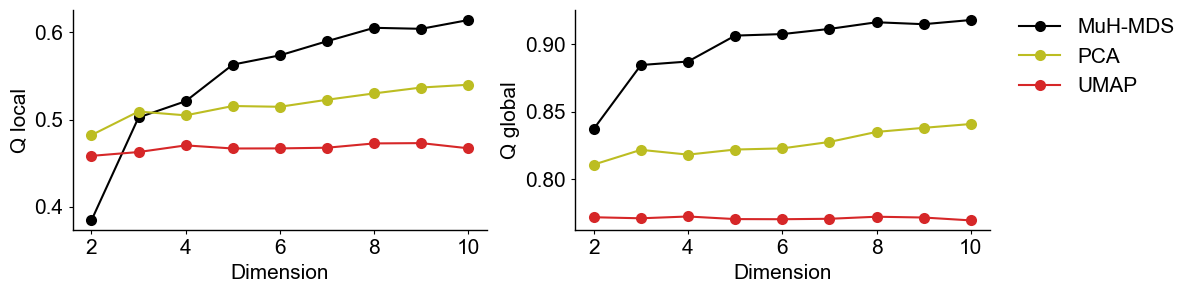

In [21]:
# plot change in metrics
# set legend names
df_metrics['method'] = df_metrics['method'].replace({'hyperbolic':'MuH-MDS','pca':'PCA','umap':'UMAP'})
fig,axs = plt.subplots(1,2,figsize=(12,3))
sn.lineplot(data=df_metrics,x='dim',y='Qlocal',hue='method',ax=axs[0],marker='o',markeredgewidth=0,markersize=8,palette=palette)
axs[0].set_xlabel('Dimension',fontsize=15)  
axs[0].set_ylabel('Q local',fontsize=15)
# remove legend for axs[0]
axs[0].legend([],[],frameon=False)
sn.lineplot(data=df_metrics,x='dim',y='Qglobal',hue='method',ax=axs[1],marker='o',markeredgewidth=0,markersize=8,palette=palette)
axs[1].set_xlabel('Dimension',fontsize=15)
axs[1].set_ylabel('Q global',fontsize=15)
# set tick font size
axs[0].tick_params(axis="x", labelsize=15,direction='in')
axs[0].tick_params(axis="y", labelsize=15,direction='in')
axs[1].tick_params(axis="x", labelsize=15,direction='in')
axs[1].tick_params(axis="y", labelsize=15,direction='in')
# set 
axs[1].legend(fontsize=15,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
clean_axis(axs[0])
clean_axis(axs[1])
plt.tight_layout()


In [22]:
'''
exploratory comparison of lineages
'''
# visualization
dim = 3
pcoords = np.loadtxt(dir+'cls_100_Nn_20_Nd_%s_min_3_max_400_coords_2730.txt'%(dim))
inds = np.loadtxt(dir+'cls_100_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
pcoords = pcoords[np.argsort(inds)]

# find MEP and GMP 
centerinds = np.arange(2730)

datarc = emb.perform_recenter(pcoords,centerinds)
# recenter
df_mhmds = pd.concat([metadata.reset_index().iloc[:,1:],pd.DataFrame(emb.to_native(datarc))],axis=1)
df_mhmds['radius'] = np.linalg.norm(emb.to_native(datarc),axis=1)


pcamat, umapmat = get_pca_umap(featmat,dim)
pcamat = pcamat - np.mean(pcamat[centerinds,:],axis=0) # recenter 
umapmat = umapmat - np.mean(umapmat[centerinds,:],axis=0) # recenter
df_umap = pd.concat([metadata.reset_index().iloc[:,1:],pd.DataFrame(umapmat)],axis=1)
df_umap['radius'] = np.linalg.norm(umapmat,axis=1)
df_pca = pd.concat([metadata.reset_index().iloc[:,1:],pd.DataFrame(pcamat)],axis=1)
df_pca['radius'] = np.linalg.norm(pcamat,axis=1)

08:43:47 - cmdstanpy - INFO - Chain [1] start processing
08:43:47 - cmdstanpy - INFO - Chain [1] done processing
/Users/mingchen/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_39642/2143804991.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_39642/2143804991.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


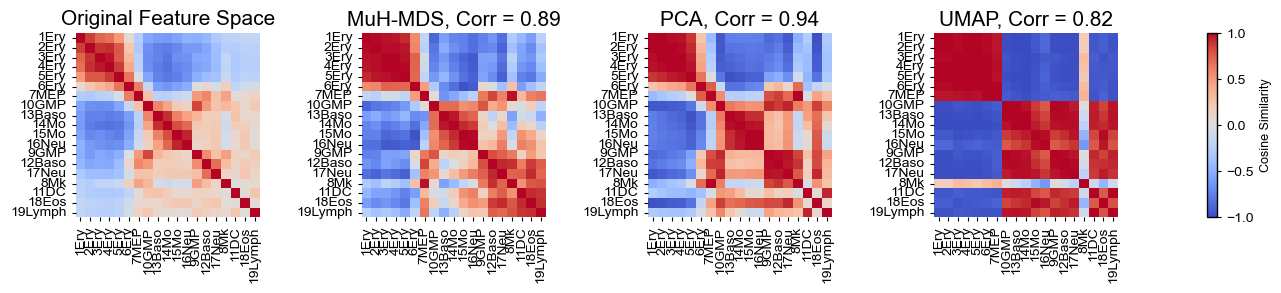

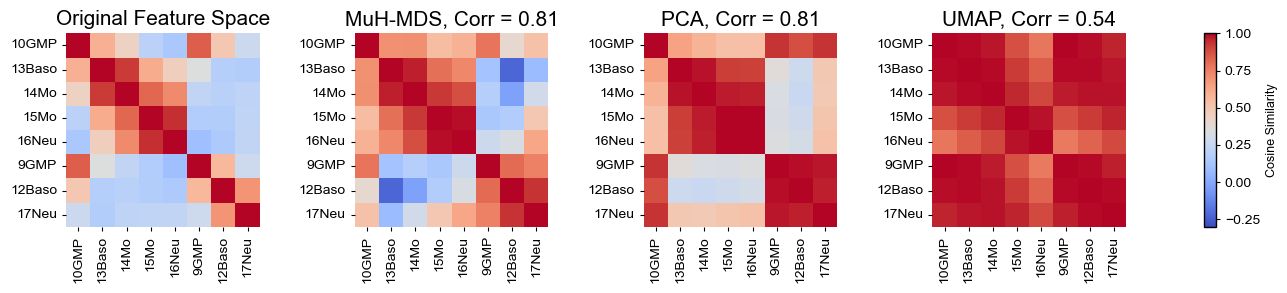

In [ ]:
# compute pairwise cosine similarity between each cluster and plot heatmap
labels = np.unique(metadata['paul15_clusters'])
ords = np.concatenate([labels[10:],labels[:10]])
lineage1 = ['7MEP','6Ery','5Ery','4Ery','3Ery','2Ery','1Ery']
lineage2 = ['10GMP','13Baso','14Mo','15Mo','16Neu']
lineage3 = ['9GMP','12Baso','17Neu']
# plot either within GMP or all groups
ords_by_group1 = lineage1[::-1] + lineage2 + lineage3 + ['8Mk','11DC','18Eos','19Lymph']
ords_by_group2 = lineage2 +lineage3
names = ['MuH-MDS','PCA','UMAP']
dfs = [df_mhmds,df_pca,df_umap]

for ords_by_group in [ords_by_group1,ords_by_group2]:
    cluster_labels = ords_by_group
    vthre = -0.3 if ords_by_group==ords_by_group2 else -1
    fig, axs = plt.subplots(
        1, 5, figsize=(13, 3),
        gridspec_kw={"width_ratios": [1, 1, 1, 1, 0.05]} 
    )
    cax = axs[-1]          
    axs = axs[:-1].flatten()  
    # recenter featmat
    featmat_rc = featmat - np.mean(featmat,axis=0)
    df_ = pd.concat([metadata.reset_index().iloc[:,1:],pd.DataFrame(featmat_rc)],axis=1)
    centroids = df_.groupby('paul15_clusters').mean().loc[cluster_labels].values
    # compute pairwise cosine similarity
    simmat_ori = cosine_similarity(centroids)
    # plot heatmap
    im = sn.heatmap(simmat_ori,xticklabels=cluster_labels,yticklabels=cluster_labels,
        ax=axs[0],cmap='coolwarm',vmin=vthre,vmax=1,cbar=False)
    axs[0].set_title('Original Feature Space', fontsize=15)
    axs[0].set_aspect('equal')

    for i,df in enumerate(dfs):
        df_ = df.drop(columns=['radius'])
        if i == 0: # map to tangent space for MuH-MDS
            tangent_coords = emb.logmap(datarc)
            df_.iloc[:,1:] = tangent_coords
        centroids = df_.groupby('paul15_clusters').mean().loc[cluster_labels].values
        if i == 0:
            centroids = emb.expmap(centroids) # back to poincare coordinates
        # compute pairwise cosine similarity
        simmat = cosine_similarity(centroids)
        # plot heatmap
        im = sn.heatmap(simmat,xticklabels=cluster_labels,yticklabels=cluster_labels,ax=axs[i+1],
                cmap='coolwarm',vmin=vthre,vmax=1,cbar=False)
        
        # set x and y to be equal aspect
        axs[i+1].set_aspect('equal')

        # compute correlation and relative distortion with original feature space
        corr = stats.spearmanr(simmat_ori[np.triu_indices(len(cluster_labels),k=1)], 
                              simmat[np.triu_indices(len(cluster_labels),k=1)]).correlation
        axs[i+1].set_title(names[i]+', Corr = %.2f'%(corr), fontsize=15)
    mappable = axs[-1].collections[0] 
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label("Cosine Similarity")
    plt.tight_layout()
    savelabel = 'GMP' if ords_by_group==ords_by_group2 else 'all'

    plt.tight_layout()

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_39642/1735994544.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_39642/1735994544.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


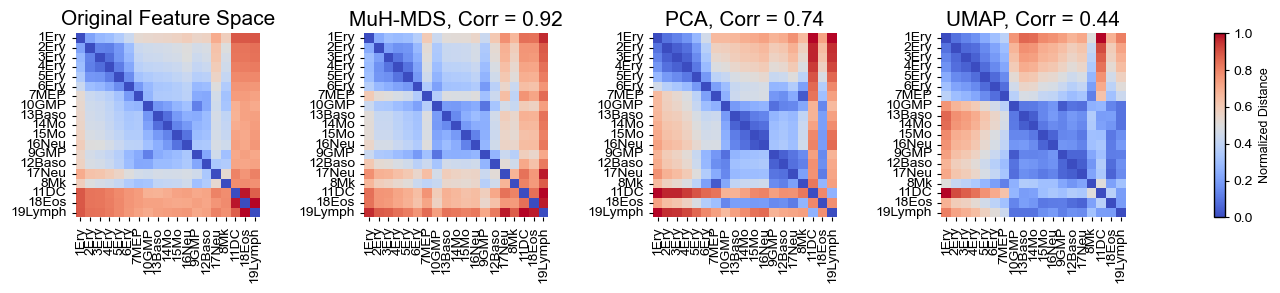

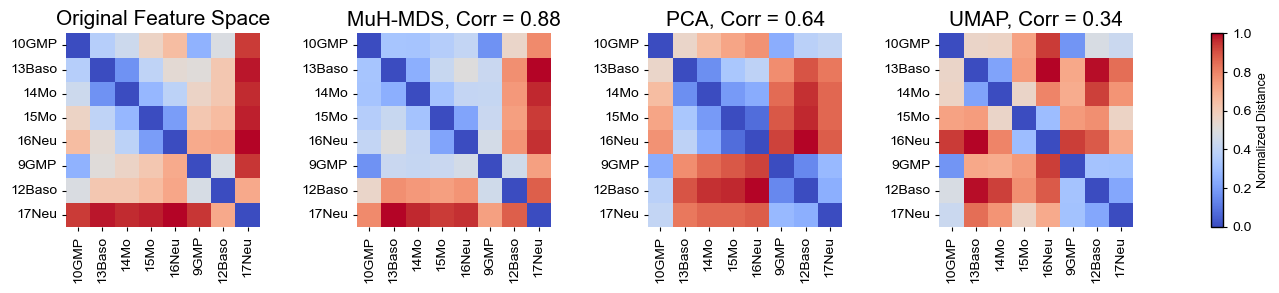

In [ ]:
# cluster pairwise distance in 3 embedding spaces
for ords_by_group in [ords_by_group1,ords_by_group2]:
    cluster_labels = ords_by_group
    fig, axs = plt.subplots(
        1, 5, figsize=(13, 3),
        gridspec_kw={"width_ratios": [1, 1, 1, 1, 0.05]} 
    )
    cax = axs[-1]          
    axs = axs[:-1].flatten()  
    df_ = pd.concat([metadata.reset_index().iloc[:,1:],pd.DataFrame(featmat)],axis=1)
    centroids = df_.groupby('paul15_clusters').mean().loc[cluster_labels].values
    # compute pairwise cosine similarity
    distmat_feat = emb.get_dmat_euc(centroids)
    distmat_feat = distmat_feat / np.max(distmat_feat)  # normalize
    # plot heatmap
    im = sn.heatmap(distmat_feat,xticklabels=cluster_labels,yticklabels=cluster_labels,ax=axs[0],
            cmap='coolwarm',cbar=False,vmin=0,vmax=1)
    axs[0].set_title('Original Feature Space', fontsize=15)
    axs[0].set_aspect('equal')

    for i,df in enumerate(dfs):
        df_ = df.drop(columns=['radius'])
        if i == 0: # map to tangent space for MuH-MDS
            tangent_coords = emb.logmap(datarc)
            df_.iloc[:,1:] = tangent_coords
        centroids = df_.groupby('paul15_clusters').mean().loc[cluster_labels].values
        if i == 0:
            centroids = emb.expmap(centroids) # back to poincare coordinates
            distmat = emb.get_dmat_poin(centroids)
        else:
        # compute pairwise euclidean distance
            distmat = emb.get_dmat_euc(centroids)
        # plot heatmap
        distmat = distmat / np.max(distmat)  # normalize
        im = sn.heatmap(distmat,xticklabels=cluster_labels,yticklabels=cluster_labels,ax=axs[i+1],
                cmap='coolwarm',cbar=False,vmin=0,vmax=1)
        # set x and y to be equal aspect
        axs[i+1].set_aspect('equal')
        # compute correlation and relative distortion with original feature space
        corr = stats.spearmanr(distmat_feat[np.triu_indices(len(cluster_labels),k=1)], 
                              distmat[np.triu_indices(len(cluster_labels),k=1)]).correlation
        axs[i+1].set_title(names[i]+', Corr = %.2f'%(corr), fontsize=15)
    mappable = axs[-1].collections[0] 
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label("Normalized Distance")
    plt.tight_layout()
    savelabel = 'GMP' if ords_by_group==ords_by_group2 else 'all'

    plt.tight_layout()

In [ ]:
# visualize 3D embedding
dfs = [df_mhmds,df_pca,df_umap]
names = ['MuH-MDS','PCA','UMAP']
for j in range(3):
    fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'scatter3d'}]*1]*1,
    subplot_titles=[names[j]],horizontal_spacing=0.,vertical_spacing=0.1)

    toplot = metadata.columns[0]

    radius_threshold = np.percentile(dfs[j]['radius'],99)
    df_toplot = dfs[j][dfs[j]['radius'] <= radius_threshold].drop(columns=['radius'])
    
    labels = np.unique(metadata['paul15_clusters'])
    labels = np.concatenate([labels[10:],labels[:10]])
    skip = len(mycolorseq)//len(labels)
    for kk in range(len(labels)):
        cat = labels[kk]
        fig.add_trace(go.Scatter3d(
            x=df_toplot[0][df_toplot[toplot]==cat],
            y=df_toplot[1][df_toplot[toplot]==cat],
            z=df_toplot[2][df_toplot[toplot]==cat],
            mode='markers',
            name=cat,
            marker=dict(
                size=3,
                color=mycolorseq[kk*skip],   
                opacity=1.0,

            )),
        row=1, col=1)
    
    fig.update_layout(
    autosize=False,
    width=600,
    height=600,
    )
    fig.update_layout(legend= {'itemsizing': 'constant'})
    fig.show()

In [ ]:
# cetegorical data
dfs = [df_mhmds,df_pca,df_umap]
names = ['MuH-MDS','PCA','UMAP']
palette = dict(zip(ords,mycolorseq[:len(ords)]))
for j in range(3):
    fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'type': 'scatter3d'}]*1]*1,
    subplot_titles=[names[j]],
    horizontal_spacing=0.,
    vertical_spacing=0.1)
    toplot = metadata.columns[0]

    df_toplot = dfs[j].drop(columns=['radius'])
    labels = np.unique(metadata['paul15_clusters'])
    labels = np.concatenate([labels[10:],labels[:10]])

    # find and plot centroids of important clusters
    lineage1 = ['7MEP','6Ery','5Ery','4Ery','3Ery','2Ery','1Ery']
    lineage2 = ['10GMP','13Baso','14Mo','15Mo','16Neu']
    lineage3 = ['9GMP','12Baso','17Neu']
    colors = ['red','blue','green']
    # in the visualization, plot centroids of important clusters
    if j == 0:
        tangent_coords = emb.logmap(datarc)
        df_toplot.iloc[:,1:] = tangent_coords
    centroids = df_toplot.groupby('paul15_clusters').mean().loc[ords]
    if j == 0:
        centroids = emb.to_native(emb.expmap(centroids)) # back to poincare coordinates -> native
    # centroids = centroids[centroids.index.isin(lineage1 +lineage2 +lineage3)]
    # plot centroids as triangles
    for idx, row in centroids.iterrows():
        fig.add_trace(go.Scatter3d(
            x=[row[0]],
            y=[row[1]],
            z=[row[2]],
            mode='markers',
            name=idx,
            marker=dict(
                size=5,
                color=palette[idx],
                symbol='x',
                line=dict(color='black', width=3)
            )),
        row=1, col=1)
    # connect centroids along lineages
    for kk,lineage in enumerate([lineage1, lineage2, lineage3]):
        lineage_coords = centroids.loc[lineage,:].values
        fig.add_trace(go.Scatter3d(
            x=lineage_coords[:,0],
            y=lineage_coords[:,1],
            z=lineage_coords[:,2],
            mode='lines',
            name='%s_lineage'%lineage[0],
            line=dict(color=colors[kk], width=4)
        ),
        row=1, col=1)
    
    fig.update_layout(
    autosize=False,
    width=600,
    height=600,
    )
    fig.update_layout(legend= {'itemsizing': 'constant'})
    #     fig.update_scenes(xaxis_tickfont_size=6,
    #                      yaxis_tickfont_size=6,
    #                      zaxis_tickfont_size=6)
    fig.show()
    # fig.write_html('./%s_3d_centroids_outliers.html'%names[j])